<a href="https://colab.research.google.com/github/leshaz44/Aliaksei/blob/main/Task_6/Task_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Список всех столбцов в датасете:
Дата - Дата измерения
CL=F_closing_price - Цена закрытия фьючерсов на нефть WTI
BZ=F_closing_price - Цена закрытия фьючерсов на нефть Brent
GC=F_closing_price - Цена закрытия фьючерсов на золото
SI=F_closing_price - Цена закрытия фьючерсов на серебро
NG=F_closing_price - Цена закрытия фьючерсов на природный газ
ZC=F_closing_price - Цена закрытия фьючерсов на кукурузу
ZW=F_closing_price - Цена закрытия фьючерсов на пшеницу
ZS=F_closing_price - Цена закрытия фьючерсов на соевые бобы
HG=F_closing_price - Цена закрытия фьючерсов на медь
PL=F_closing_price - Цена закрытия фьючерсов на свинец
PA=F_closing_price - Цена закрытия фьючерсов на алюминий

Количество пропущенных значений по каждому столбцу:
CL=F_closing_price      24
BZ=F_closing_price    1799
GC=F_closing_price      28
SI=F_closing_price      26
NG=F_closing_price      22
ZC=F_closing_price      47
ZW=F_closing_price      35
ZS=F_closing_price      21
HG=F_closing_price      23
PL=F_closing_price 

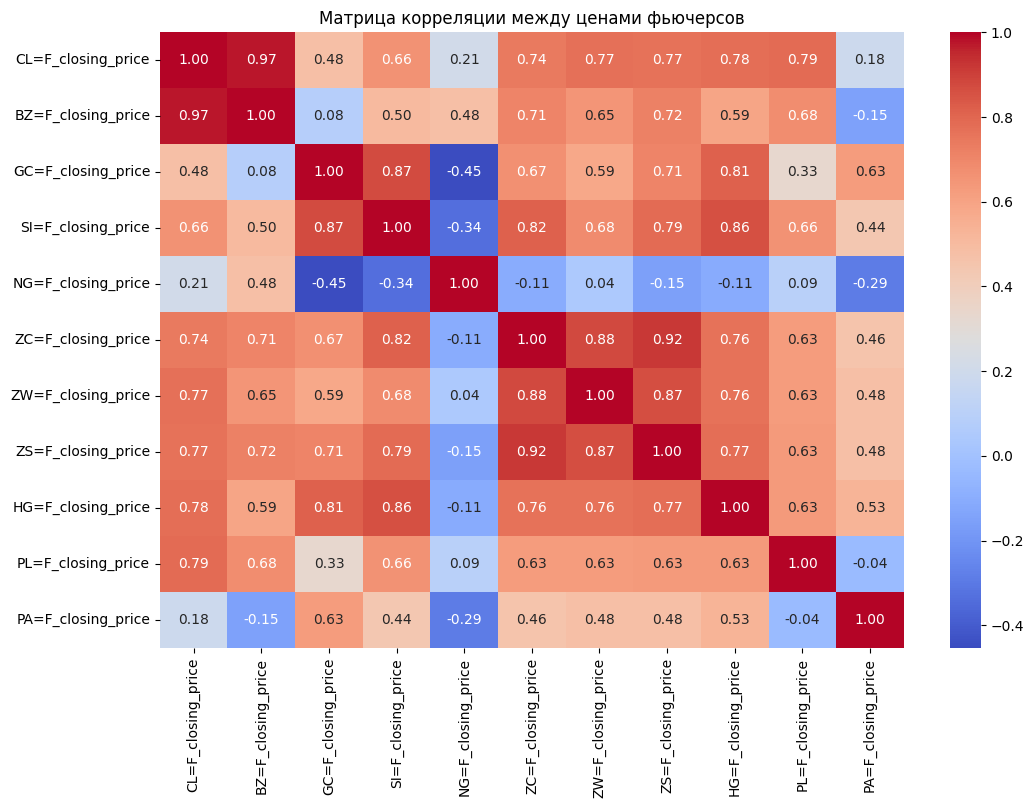

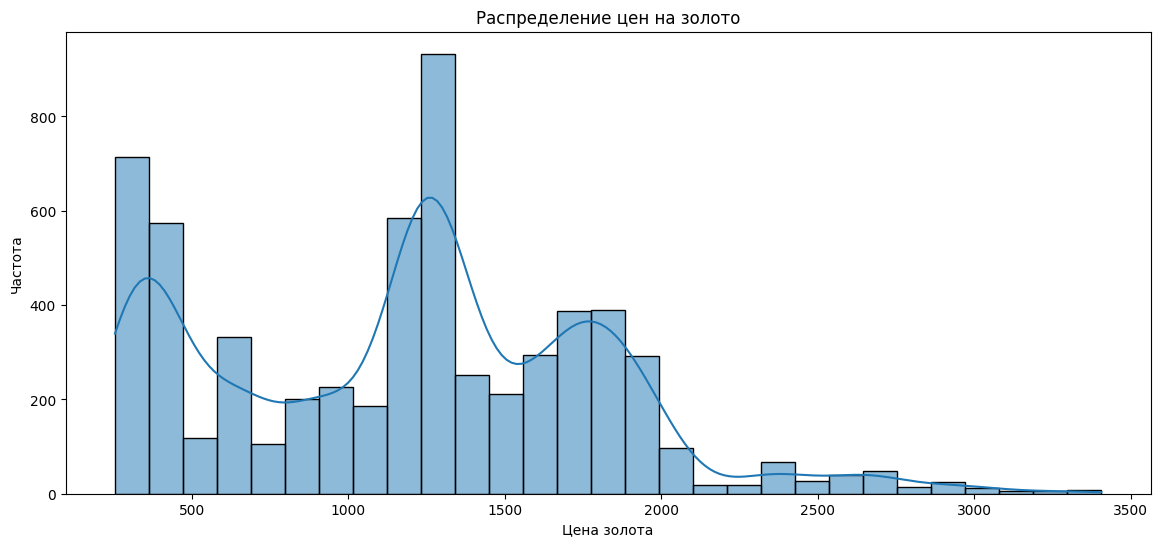

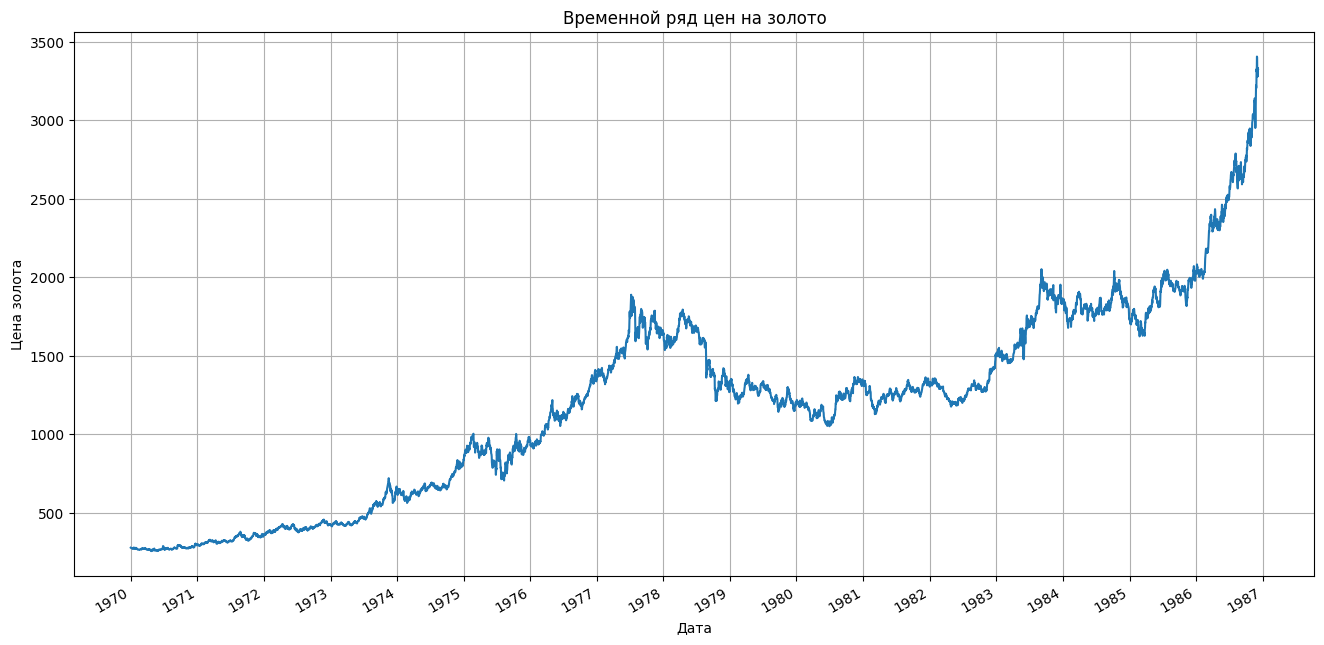

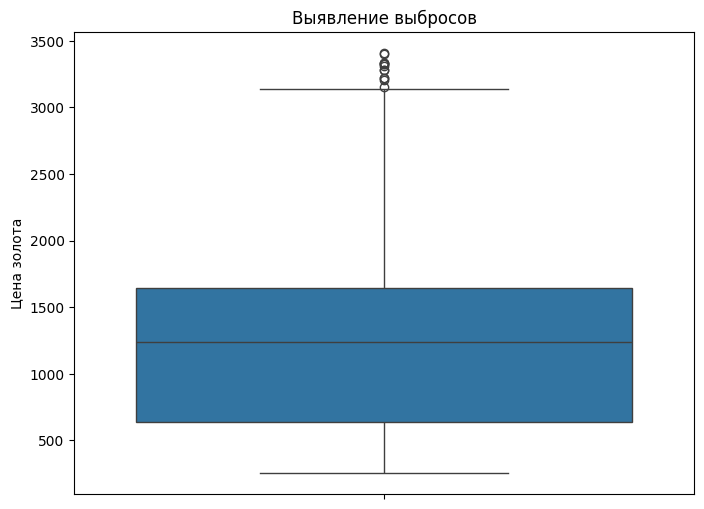

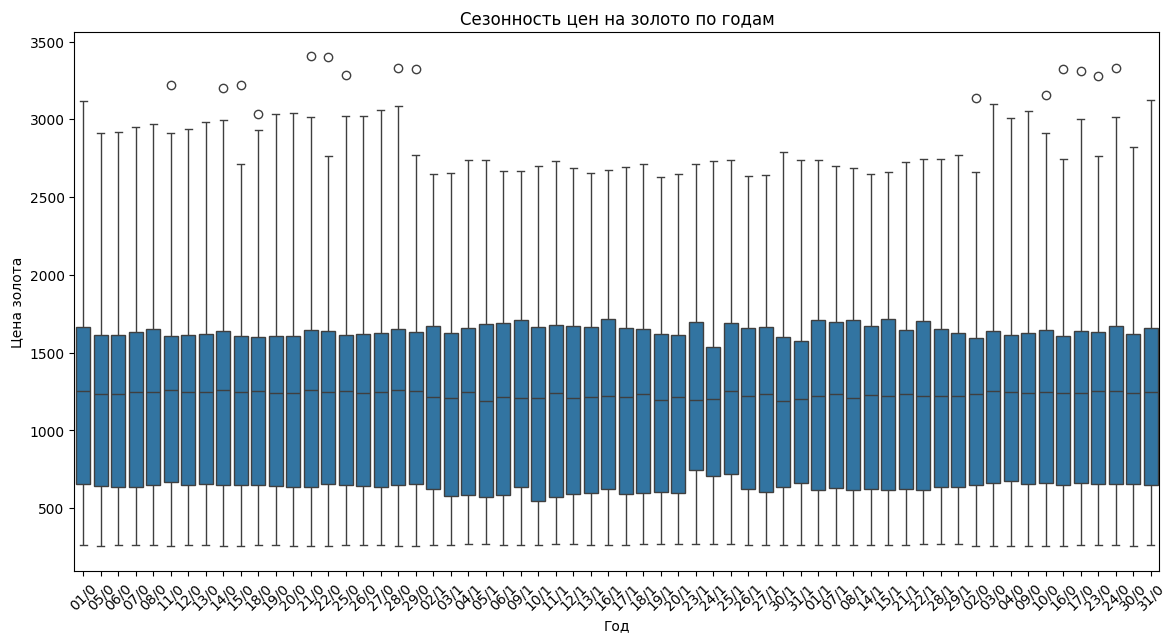

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from scipy import stats
import matplotlib.dates as mdates

# Загрузка данных
df = pd.read_csv('Futures_Resources_Data.csv', parse_dates=['Date'])
df.set_index('Date', inplace=True)

# Выбираем только нужные столбцы
gold_data = df[['GC=F_closing_price']].dropna()

# Создаем столбец с годом через преобразование индекса в строку
gold_data['Year'] = gold_data.index.astype(str).str[:4]

# Информация о столбцах датасета
print("\nСписок всех столбцов в датасете:")
print("Дата - Дата измерения")
print("CL=F_closing_price - Цена закрытия фьючерсов на нефть WTI")
print("BZ=F_closing_price - Цена закрытия фьючерсов на нефть Brent")
print("GC=F_closing_price - Цена закрытия фьючерсов на золото")
print("SI=F_closing_price - Цена закрытия фьючерсов на серебро")
print("NG=F_closing_price - Цена закрытия фьючерсов на природный газ")
print("ZC=F_closing_price - Цена закрытия фьючерсов на кукурузу")
print("ZW=F_closing_price - Цена закрытия фьючерсов на пшеницу")
print("ZS=F_closing_price - Цена закрытия фьючерсов на соевые бобы")
print("HG=F_closing_price - Цена закрытия фьючерсов на медь")
print("PL=F_closing_price - Цена закрытия фьючерсов на свинец")
print("PA=F_closing_price - Цена закрытия фьючерсов на алюминий")

# Подсчет пропущенных значений
print("\nКоличество пропущенных значений по каждому столбцу:")
print(df.isnull().sum())

# Базовый обзор данных
print("\nОбщая информация о датасете:")
print(df.info())
print("\nОписание данных:")
print(df.describe())

# Проверка на пропуски
print("\nКоличество пропусков в выбранных данных:")
print(gold_data.isnull().sum())

# Матрица корреляции
plt.figure(figsize=(12, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Матрица корреляции между ценами фьючерсов')
plt.show()

# Распределение цены золота
plt.figure(figsize=(14, 6))
sns.histplot(gold_data['GC=F_closing_price'], kde=True)
plt.title('Распределение цен на золото')
plt.xlabel('Цена золота')
plt.ylabel('Частота')
plt.show()

# Временной ряд
plt.figure(figsize=(16, 8))
plt.plot(gold_data.index, gold_data['GC=F_closing_price'])
plt.title('Временной ряд цен на золото')
plt.xlabel('Дата')
plt.ylabel('Цена золота')
plt.grid(True)
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.gcf().autofmt_xdate()
plt.show()

# Боксплот для выявления выбросов
plt.figure(figsize=(8, 6))
sns.boxplot(y=gold_data['GC=F_closing_price'])
plt.title('Выявление выбросов')
plt.ylabel('Цена золота')
plt.show()

# Анализ сезонности
plt.figure(figsize=(14, 7))
sns.boxplot(x='Year', y='GC=F_closing_price', data=gold_data)
plt.title('Сезонность цен на золото по годам')
plt.xlabel('Год')
plt.ylabel('Цена золота')
plt.xticks(rotation=45)
plt.show()


Training GRU model...
Epoch 1/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 16s 95ms/step - loss: 0.0034 - val_loss: 1.3924e-04
Epoch 2/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 19s 82ms/step - loss: 6.4921e-04 - val_loss: 5.8129e-05
Epoch 3/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 11s 89ms/step - loss: 5.3707e-04 - val_loss: 2.1215e-04
Epoch 4/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 21s 92ms/step - loss: 4.4803e-04 - val_loss: 5.7390e-05
Epoch 5/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 11s 88ms/step - loss: 3.9229e-04 - val_loss: 4.2023e-05
Epoch 6/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 11s 86ms/step - loss: 3.6211e-04 - val_loss: 3.7664e-05
Epoch 7/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 21s 90ms/step - loss: 3.6330e-04 - val_loss: 2.5264e-04
Epoch 8/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 21s 95ms/step - loss: 3.4201e-04 - val_loss: 8.6459e-05
Epoch 9/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 10s 85ms/step - loss: 3.0899e-04 - val_loss: 8.6887e-05
Epoch 10/20
123/123 ━━━━━━━━━━━━━━━━━━━━ 10s 85ms/step - loss: 2.9579e-04 - val_loss: 3.6667e-05
Epoch 11/20
123/123 

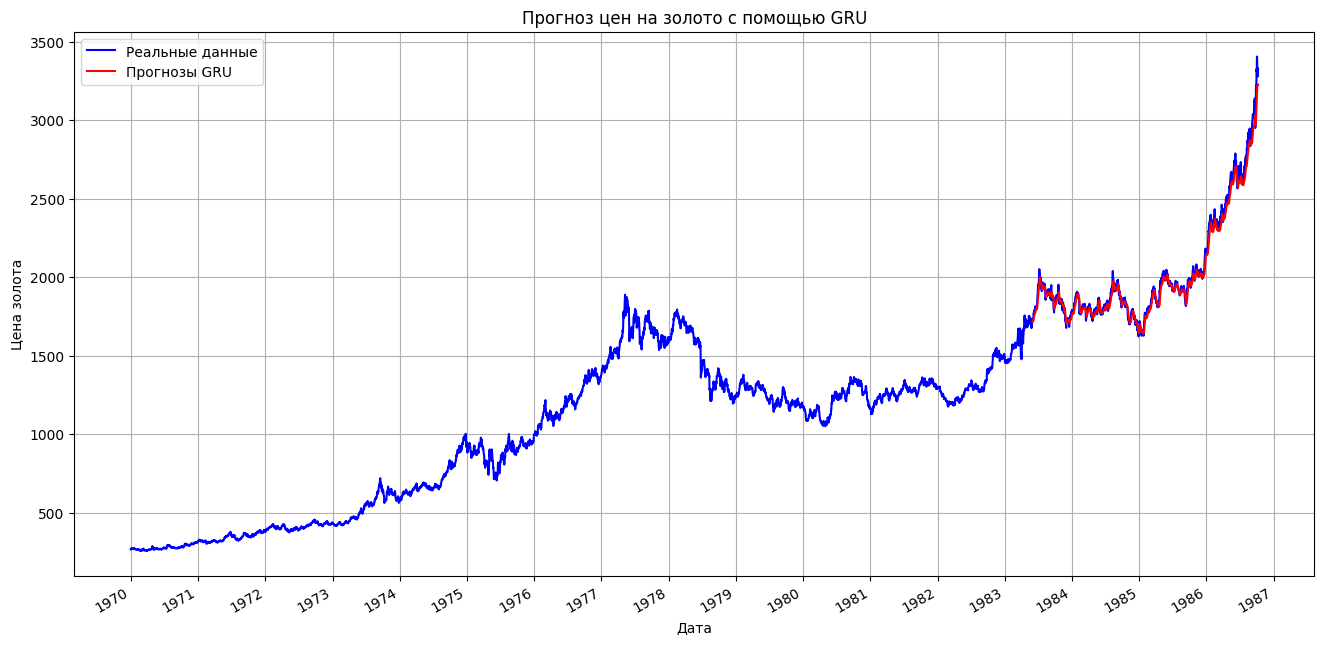


Результаты для модели LSTM:
RMSE: 64.72
MAE: 46.08
R2: 0.9665
MAPE: 2.10%


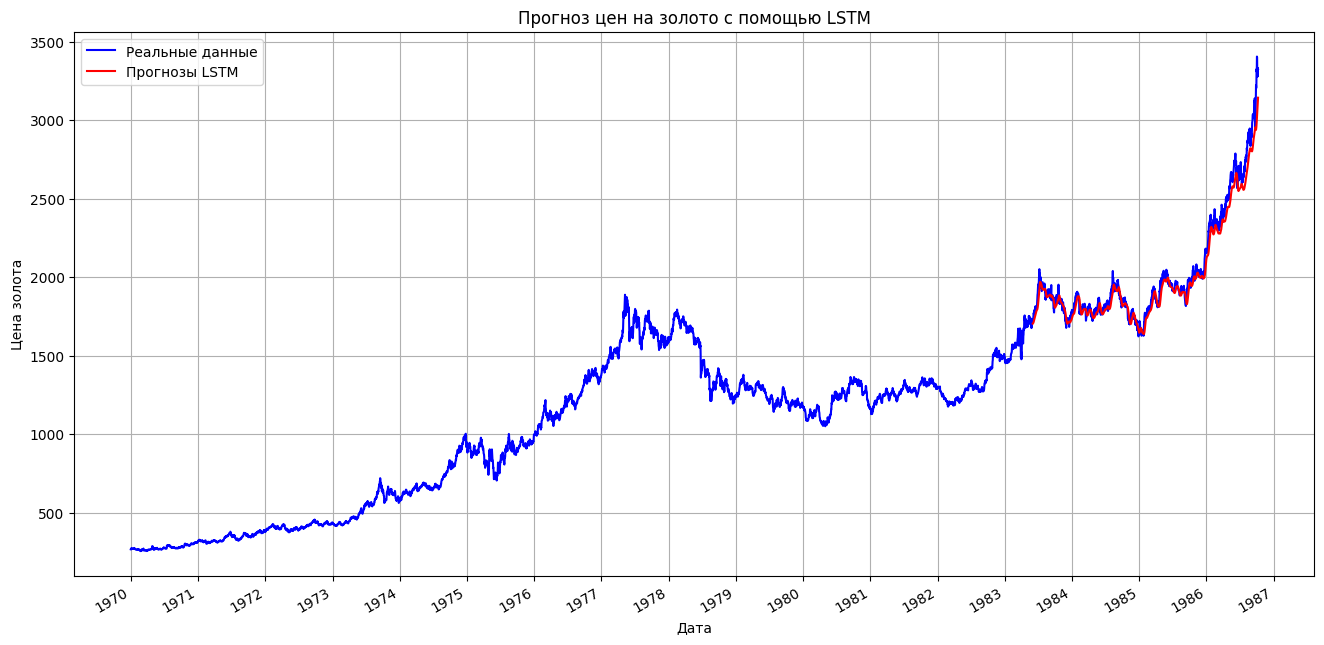


Результаты для модели RNN:
RMSE: 51.20
MAE: 33.88
R2: 0.9790
MAPE: 1.50%


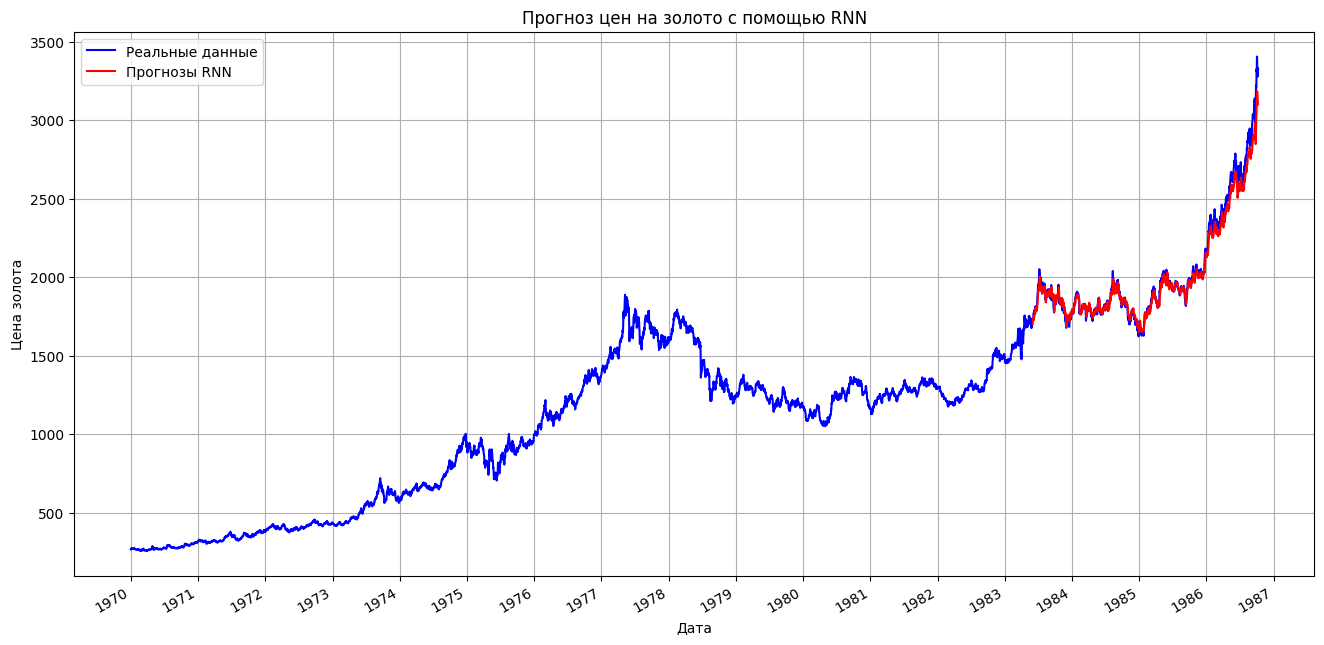


Результаты для модели CNN:
RMSE: 53.25
MAE: 39.98
R2: 0.9773
MAPE: 1.91%


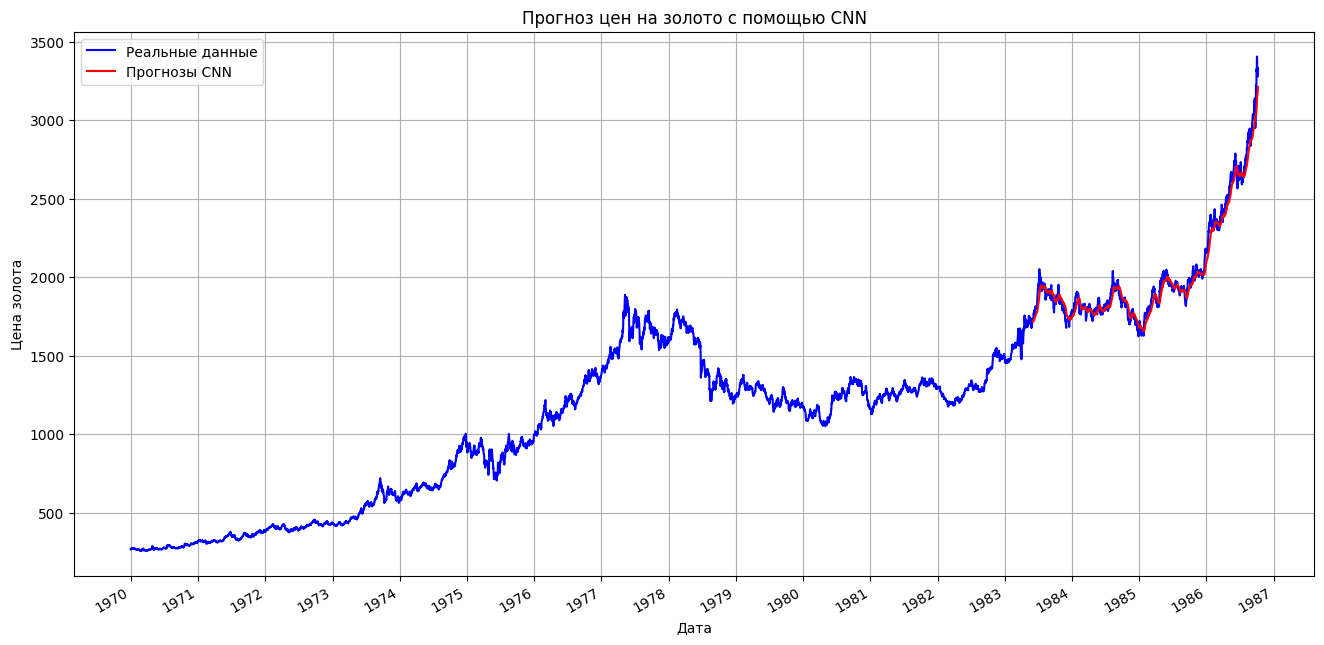


Результаты для модели Autoencoder:
RMSE: 32.92
MAE: 24.77
R2: 0.9913
MAPE: 1.21%


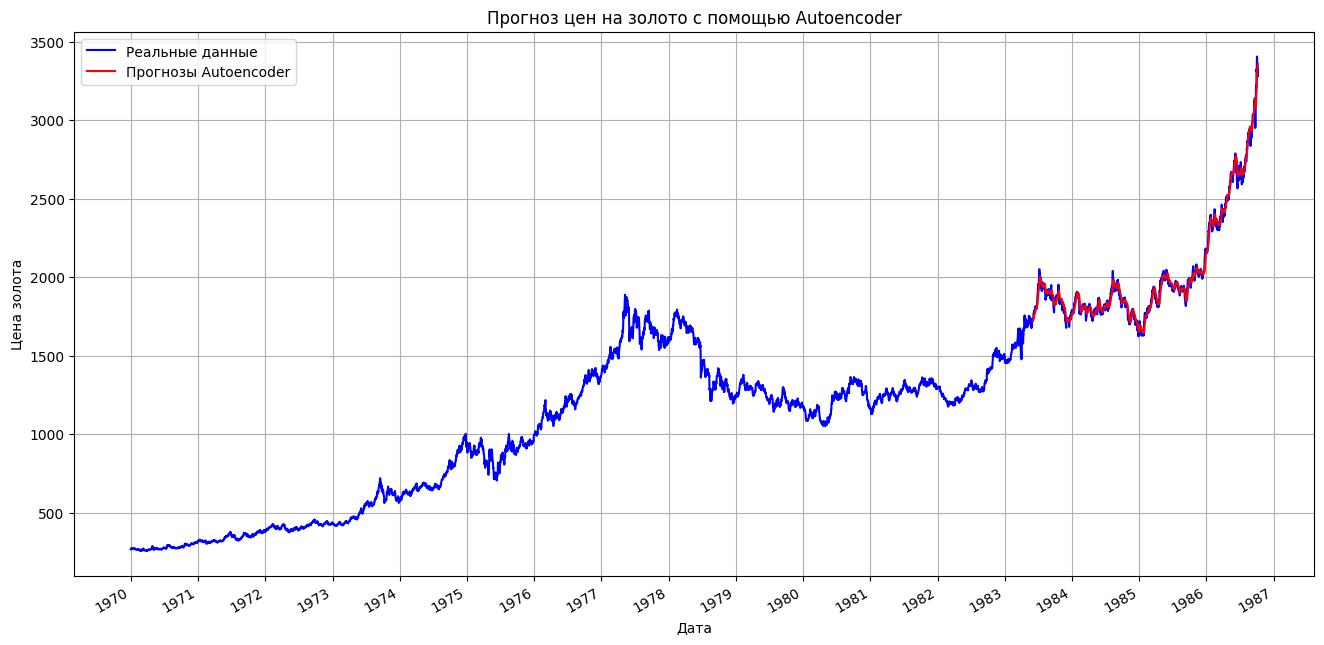

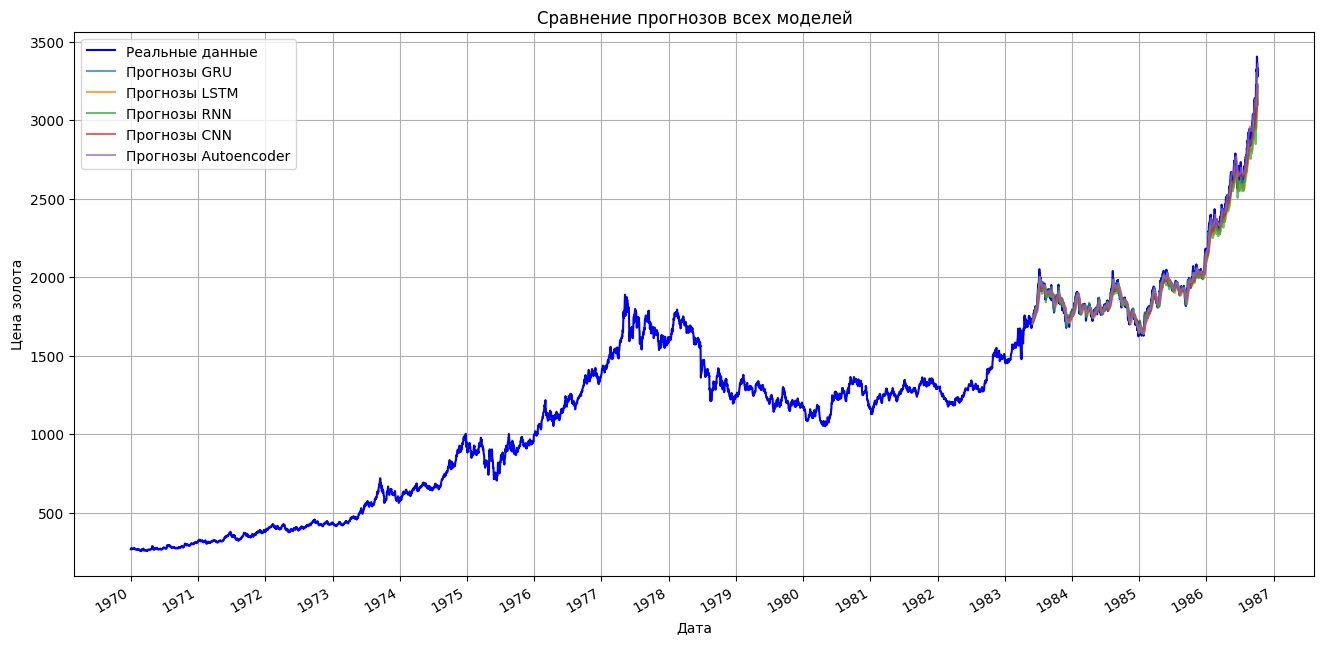


Сравнение метрик моделей:
        Модель       RMSE        MAE        R2      MAPE
0          GRU  40.876265  28.911029  0.986631  1.329700
1         LSTM  64.722541  46.081488  0.966484  2.098000
2          RNN  51.197172  33.879079  0.979028  1.501586
3          CNN  53.253456  39.984882  0.977310  1.907090
4  Autoencoder  32.921346  24.771838  0.991328  1.210452

Визуализация сравнения метрик:


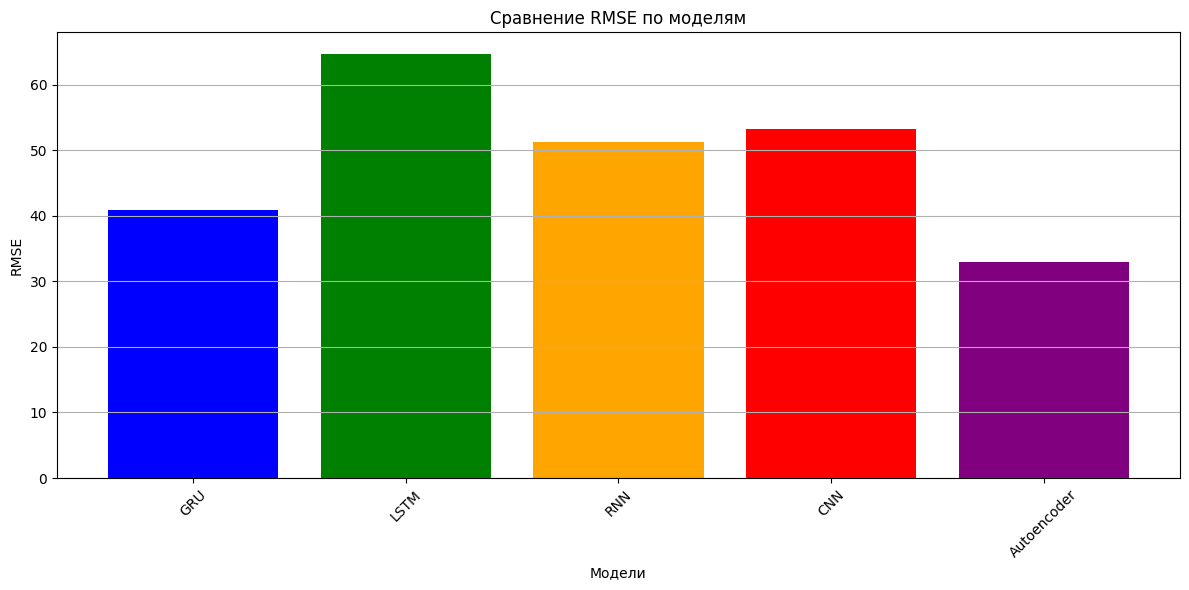

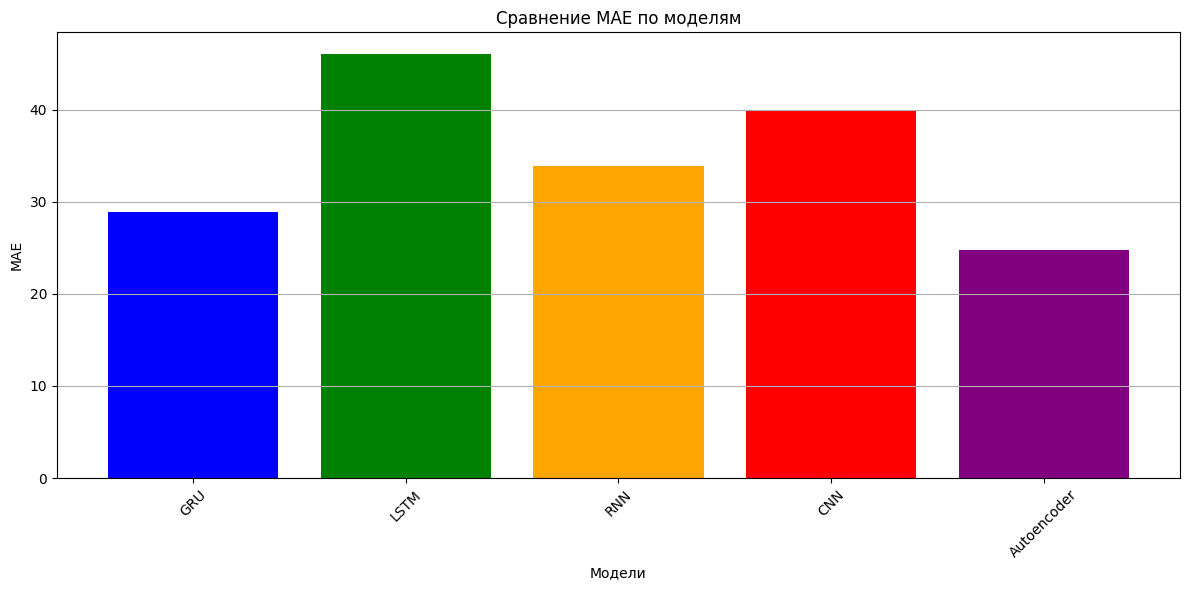

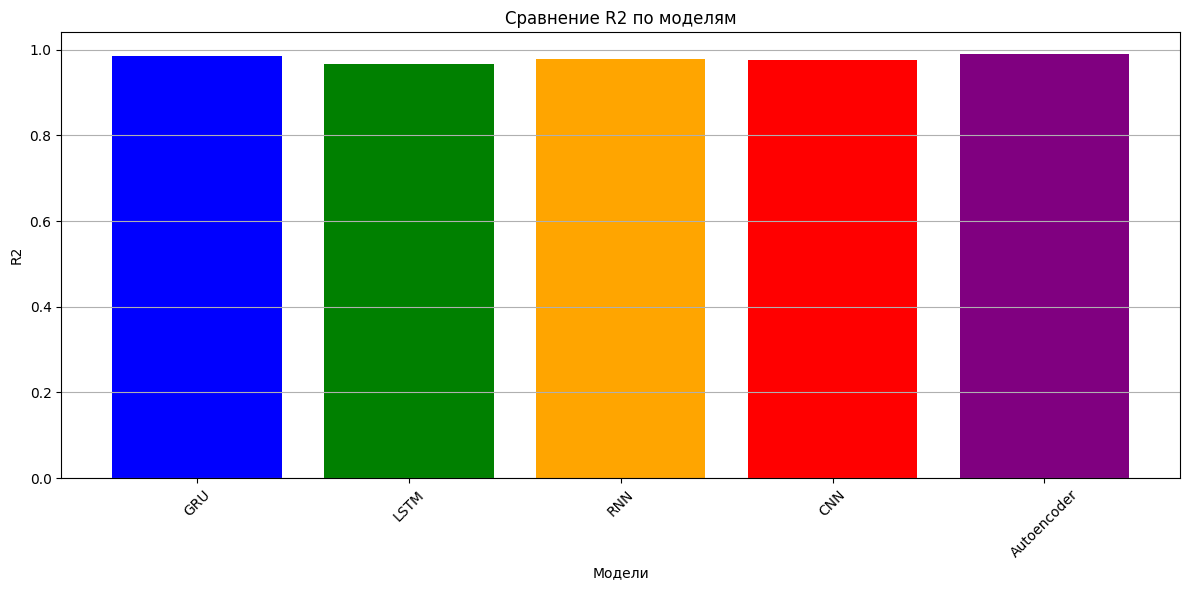

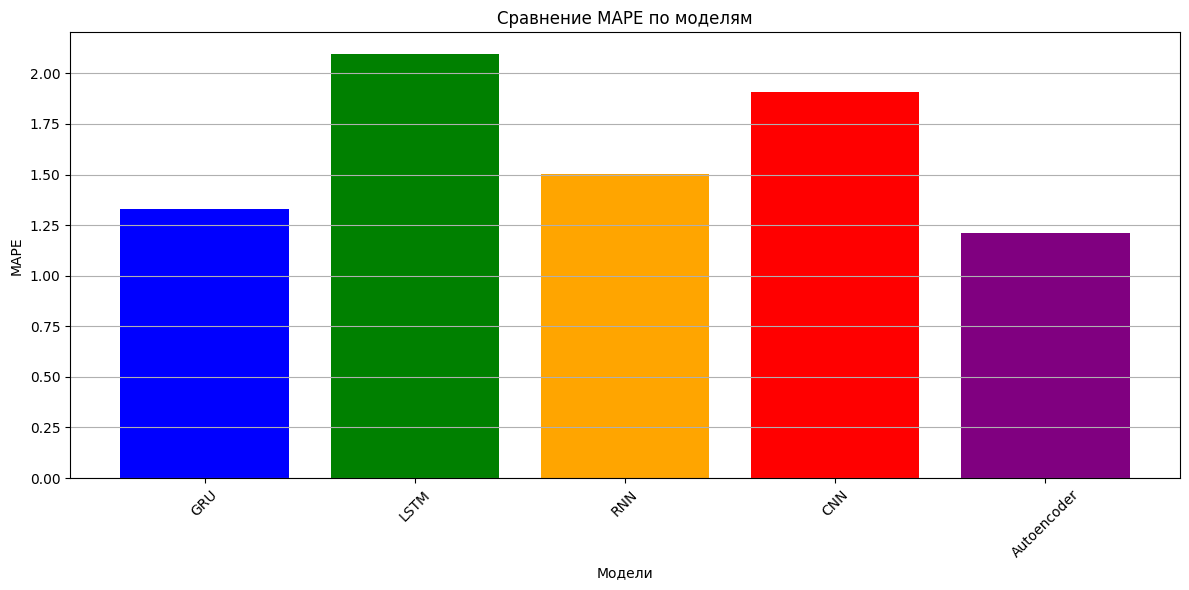


РЕЗУЛЬТАТЫ АНАЛИЗА МОДЕЛЕЙ:
----------------------------------------

СРАВНЕНИЕ МЕТРИК МОДЕЛЕЙ:
        Модель       RMSE        MAE        R2      MAPE
0          GRU  40.876265  28.911029  0.986631  1.329700
1         LSTM  64.722541  46.081488  0.966484  2.098000
2          RNN  51.197172  33.879079  0.979028  1.501586
3          CNN  53.253456  39.984882  0.977310  1.907090
4  Autoencoder  32.921346  24.771838  0.991328  1.210452


РЕКОМЕНДУЕМАЯ МОДЕЛЬ:
******************** Autoencoder ********************
ОСНОВАНИЕ РЕКОМЕНДАЦИИ:
Модель Autoencoder показала наилучший баланс между:
- Максимальным коэффициентом детерминации (R2)
- Минимальными ошибками прогнозирования (RMSE, MAE, MAPE)


РЕКОМЕНДАЦИИ ПО ИСПОЛЬЗОВАНИЮ:
**************************************************
НАИБОЛЕЕ ЭФФЕКТИВНОЙ МОДЕЛЬЮ ЯВЛЯЕТСЯ: Autoencoder
**************************************************
РЕКОМЕНДУЕТСЯ ИСПОЛЬЗОВАТЬ ДАННУЮ МОДЕЛЬ ДЛЯ:
- Прогнозирования цен на золото
- Анализа временных рядов
- Принятия и

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    GRU, LSTM, SimpleRNN, Dense, Dropout, Input,
    Conv1D, MaxPooling1D, Flatten
)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
import matplotlib.dates as mdates
from tensorflow.keras.callbacks import EarlyStopping

# Загрузка данных
df = pd.read_csv('Futures_Resources_Data.csv', parse_dates=['Date'])
df.set_index('Date', inplace=True)

# Выбираем только данные по золоту
gold_data = df['GC=F_closing_price'].dropna()

# Нормализация данных
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(gold_data.values.reshape(-1,1))

# Создание обучающих последовательностей
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data)-seq_length):
        X.append(data[i:(i+seq_length)])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

sequence_length = 60
X, y = create_sequences(scaled_data, sequence_length)

# Разделение на выборки
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Функция для построения моделей
def build_model(model_type):
    input_layer = Input(batch_shape=(None, X_train.shape[1], 1))

    if model_type == 'GRU':
        x = GRU(50, return_sequences=True)(input_layer)
        x = Dropout(0.2)(x)
        x = GRU(50, return_sequences=False)(x)

    elif model_type == 'LSTM':
        x = LSTM(50, return_sequences=True)(input_layer)
        x = Dropout(0.2)(x)
        x = LSTM(50, return_sequences=False)(x)

    elif model_type == 'RNN':
        x = SimpleRNN(50, return_sequences=True)(input_layer)
        x = Dropout(0.2)(x)
        x = SimpleRNN(50, return_sequences=False)(x)

    elif model_type == 'CNN':
        x = Conv1D(filters=64, kernel_size=3, activation='relu')(input_layer)
        x = MaxPooling1D(pool_size=2)(x)
        x = Flatten()(x)

    elif model_type == 'Autoencoder':
        # Encoder часть
        x = Dense(128, activation='relu')(input_layer)
        x = Dense(64, activation='relu')(x)

        # Bottleneck
        encoded = Dense(32, activation='relu')(x)

        # Decoder часть
        x = Dense(64, activation='relu')(encoded)
        x = Dense(128, activation='relu')(x)

        # Выходной слой
        x = Flatten()(x)

    x = Dropout(0.2)(x)
    output_layer = Dense(units=1)(x)

    model = Model(inputs=input_layer, outputs=output_layer)
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Обучение моделей
models = {}
results = {}

for model_type in ['GRU', 'LSTM', 'RNN', 'CNN', 'Autoencoder']:
    print(f"\nTraining {model_type} model...")

    # Создаем модель
    model = build_model(model_type)
    models[model_type] = model

    # Добавляем Early Stopping
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    # Обучаем модель
    history = model.fit(
        X_train, y_train,
        epochs=20,
        batch_size=32,
        validation_split=0.2,
        callbacks=[early_stop],
        verbose=1
    )

    # Сохраняем историю обучения
    results[model_type] = {
        'history': history,
        'model': model
    }

# Функция для оценки моделей
def evaluate_model(model, X_test, y_test, scaler):
    # Прогнозирование
    test_predict = model.predict(X_test)

    # Обратное преобразование масштабирования
    test_predict = scaler.inverse_transform(test_predict)
    y_true = scaler.inverse_transform(y_test.reshape(-1,1))

    # Метрики
    rmse = np.sqrt(mean_squared_error(y_true, test_predict))
    mae = mean_absolute_error(y_true, test_predict)
    r2 = r2_score(y_true, test_predict)
    mape = mean_absolute_percentage_error(y_true, test_predict) * 100

    return {
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2,
        'MAPE': mape,
        'predictions': test_predict
    }

# Оценка всех моделей
evaluation_results = {}

for model_type in models:
    print(f"\nОцениваем модель {model_type}...")
    evaluation_results[model_type] = evaluate_model(
        models[model_type],
        X_test,
        y_test,
        scaler
    )

# Визуализация результатов
def plot_results(model_type):
    plt.figure(figsize=(16, 8))
    plt.plot(gold_data.index[sequence_length:],
             scaler.inverse_transform(y.reshape(-1,1)),
             label='Реальные данные', color='blue')

    plt.plot(gold_data.index[-len(evaluation_results[model_type]['predictions']):],
             evaluation_results[model_type]['predictions'],
             label=f'Прогнозы {model_type}', color='red')

    plt.title(f'Прогноз цен на золото с помощью {model_type}')
    plt.xlabel('Дата')
    plt.ylabel('Цена золота')
    plt.legend()
    plt.grid(True)
    plt.gca().xaxis.set_major_locator(mdates.YearLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.gcf().autofmt_xdate()
    plt.show()

# Визуализация ошибок
def plot_error_comparison():
    plt.figure(figsize=(14, 7))
    for model_type in evaluation_results:
        errors = evaluation_results[model_type]['predictions'] - scaler.inverse_transform(y_test.reshape(-1,1))
        plt.plot(
            gold_data.index[-len(errors):],
            errors.flatten(),
            label=model_type
        )
    plt.axhline(y=0, color='black', linestyle='--')
    plt.title('Сравнение ошибок моделей')
    plt.xlabel('Дата')
    plt.ylabel('Ошибка прогноза')
    plt.legend()
    plt.grid(True)
    plt.gca().xaxis.set_major_locator(mdates.YearLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.gcf().autofmt_xdate()
    plt.show()

# Визуализация всех моделей
for model_type in models:
    print(f"\nРезультаты для модели {model_type}:")
    print(f"RMSE: {evaluation_results[model_type]['RMSE']:.2f}")
    print(f"MAE: {evaluation_results[model_type]['MAE']:.2f}")
    print(f"R2: {evaluation_results[model_type]['R2']:.4f}")
    print(f"MAPE: {evaluation_results[model_type]['MAPE']:.2f}%")
    plot_results(model_type)

# Дополнительная визуализация - сравнение прогнозов
plt.figure(figsize=(16, 8))
plt.plot(
    gold_data.index[sequence_length:],
    scaler.inverse_transform(y.reshape(-1,1)),
    label='Реальные данные',
    color='blue'
)

for model_type in evaluation_results:
    plt.plot(
        gold_data.index[-len(evaluation_results[model_type]['predictions']):],
        evaluation_results[model_type]['predictions'],
        label=f'Прогнозы {model_type}',
        alpha=0.7
    )

plt.title('Сравнение прогнозов всех моделей')
plt.xlabel('Дата')
plt.ylabel('Цена золота')
plt.legend()
plt.grid(True)
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.gcf().autofmt_xdate()
plt.show()

# Сравнение метрик
comparison_df = pd.DataFrame({
    'Модель': list(evaluation_results.keys()),
    'RMSE': [res['RMSE'] for res in evaluation_results.values()],
    'MAE': [res['MAE'] for res in evaluation_results.values()],
    'R2': [res['R2'] for res in evaluation_results.values()],
    'MAPE': [res['MAPE'] for res in evaluation_results.values()]
})

print("\nСравнение метрик моделей:")
print(comparison_df)
# Функция для построения графиков сравнения метрик
def plot_metric_comparison(metric_name):
    plt.figure(figsize=(12, 6))
    plt.bar(
        comparison_df['Модель'],
        comparison_df[metric_name],
        color=['blue', 'green', 'orange', 'red', 'purple']
    )

    plt.title(f'Сравнение {metric_name} по моделям')
    plt.xlabel('Модели')
    plt.ylabel(metric_name)
    plt.grid(axis='y')
    plt.ylim(bottom=0)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Функция для построения сравнительных графиков всех метрик
def plot_all_metrics():
    metrics = ['RMSE', 'MAE', 'R2', 'MAPE']

    plt.figure(figsize=(16, 12))

    for i, metric in enumerate(metrics):
        plt.subplot(2, 2, i+1)
        plt.bar(
            comparison_df['Модель'],
            comparison_df[metric],
            color=['blue', 'green', 'orange', 'red', 'purple']
        )

        plt.title(f'Сравнение {metric}')
        plt.xlabel('Модели')
        plt.ylabel(metric)
        plt.grid(axis='y')
        plt.ylim(bottom=0)
        plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

# Добавляем визуализацию сравнения метрик
print("\nВизуализация сравнения метрик:")

# Построим отдельные графики для каждой метрики
plot_metric_comparison('RMSE')
plot_metric_comparison('MAE')
plot_metric_comparison('R2')
plot_metric_comparison('MAPE')

# Функция для определения лучшей модели на основе метрик
def determine_best_model(results):
    # Собираем все метрики в DataFrame
    comparison_df = pd.DataFrame({
        'Модель': list(results.keys()),
        'RMSE': [res['RMSE'] for res in results.values()],
        'MAE': [res['MAE'] for res in results.values()],
        'R2': [res['R2'] for res in results.values()],
        'MAPE': [res['MAPE'] for res in results.values()]
    })

    # Определяем лучшую модель по R2 и RMSE
    best_r2_model = comparison_df.loc[comparison_df['R2'].idxmax()]['Модель']
    best_rmse_model = comparison_df.loc[comparison_df['RMSE'].idxmin()]['Модель']

    # Если совпадают - это наш выбор
    if best_r2_model == best_rmse_model:
        return best_r2_model
    else:
        # Если не совпадают - выбираем по среднему баллу
        comparison_df['Средний_балл'] = (comparison_df['R2'] +
                                        1/comparison_df['RMSE'] +
                                        1/comparison_df['MAE'] +
                                        1/comparison_df['MAPE'])
        return comparison_df.loc[comparison_df['Средний_балл'].idxmax()]['Модель']

# Определяем лучшую модель
best_model = determine_best_model(evaluation_results)

# Выводим результаты анализа
print("\nРЕЗУЛЬТАТЫ АНАЛИЗА МОДЕЛЕЙ:")
print("-" * 40)

# Сравнение метрик
comparison_df = pd.DataFrame({
    'Модель': list(evaluation_results.keys()),
    'RMSE': [res['RMSE'] for res in evaluation_results.values()],
    'MAE': [res['MAE'] for res in evaluation_results.values()],
    'R2': [res['R2'] for res in evaluation_results.values()],
    'MAPE': [res['MAPE'] for res in evaluation_results.values()]
})

print("\nСРАВНЕНИЕ МЕТРИК МОДЕЛЕЙ:")
print(comparison_df)

# Вывод лучшей модели
print("\n\nРЕКОМЕНДУЕМАЯ МОДЕЛЬ:")
print(f"{'*'*20} {best_model} {'*'*20}")
print(f"ОСНОВАНИЕ РЕКОМЕНДАЦИИ:")
print(f"Модель {best_model} показала наилучший баланс между:")
print(f"- Максимальным коэффициентом детерминации (R2)")
print(f"- Минимальными ошибками прогнозирования (RMSE, MAE, MAPE)")

# ... остальной код ...

# Добавляем вывод в конце визуализации
print("\n\nРЕКОМЕНДАЦИИ ПО ИСПОЛЬЗОВАНИЮ:")
print(f"{'*'*50}")
print(f"НАИБОЛЕЕ ЭФФЕКТИВНОЙ МОДЕЛЬЮ ЯВЛЯЕТСЯ: {best_model}")
print(f"{'*'*50}")
print("РЕКОМЕНДУЕТСЯ ИСПОЛЬЗОВАТЬ ДАННУЮ МОДЕЛЬ ДЛЯ:")
print("- Прогнозирования цен на золото")
print("- Анализа временных рядов")
print("- Принятия инвестиционных решений")
print("\nОГРАНИЧЕНИЯ ПРИМЕНЕНИЯ:")
if best_model == 'GRU':
    print("Требует большого объема данных для обучения")
elif best_model == 'LSTM':
    print("Может быть ресурсоемкой при больших выборках")
elif best_model == 'RNN':
    print("Менее эффективна для долгосрочных зависимостей")
elif best_model == 'CNN':
    print("Лучше работает с сезонными данными")
elif best_model == 'Autoencoder':
    print("Требует дополнительной настройки гиперпараметров")

